In [1]:
import sys

print(sys.executable)

/mnt/ADATA_SSD/Programs/anaconda3/envs/py_env/bin/python


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import datasets 
from sklearn.cluster import KMeans
from sklearn import metrics

iris = datasets.load_iris() 
iris_DF = pd.DataFrame(data=iris.data, columns=iris.feature_names) 
iris_DF["Species"] = iris.target
print(iris_DF.head(15))
print(iris_DF.info())

    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                 5.1               3.5                1.4               0.2   
1                 4.9               3.0                1.4               0.2   
2                 4.7               3.2                1.3               0.2   
3                 4.6               3.1                1.5               0.2   
4                 5.0               3.6                1.4               0.2   
5                 5.4               3.9                1.7               0.4   
6                 4.6               3.4                1.4               0.3   
7                 5.0               3.4                1.5               0.2   
8                 4.4               2.9                1.4               0.2   
9                 4.9               3.1                1.5               0.1   
10                5.4               3.7                1.5               0.2   
11                4.8               3.4 

<Figure size 500x500 with 0 Axes>

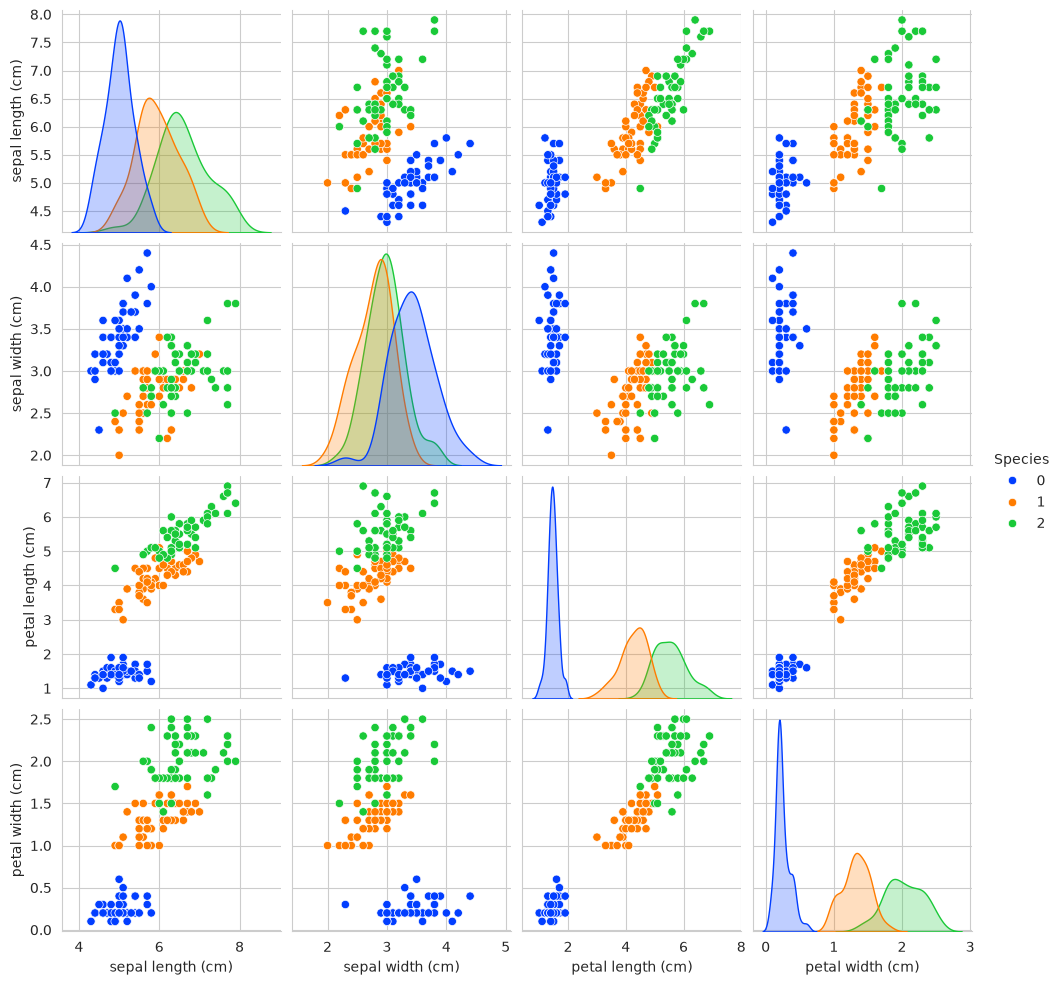

<Figure size 500x500 with 0 Axes>

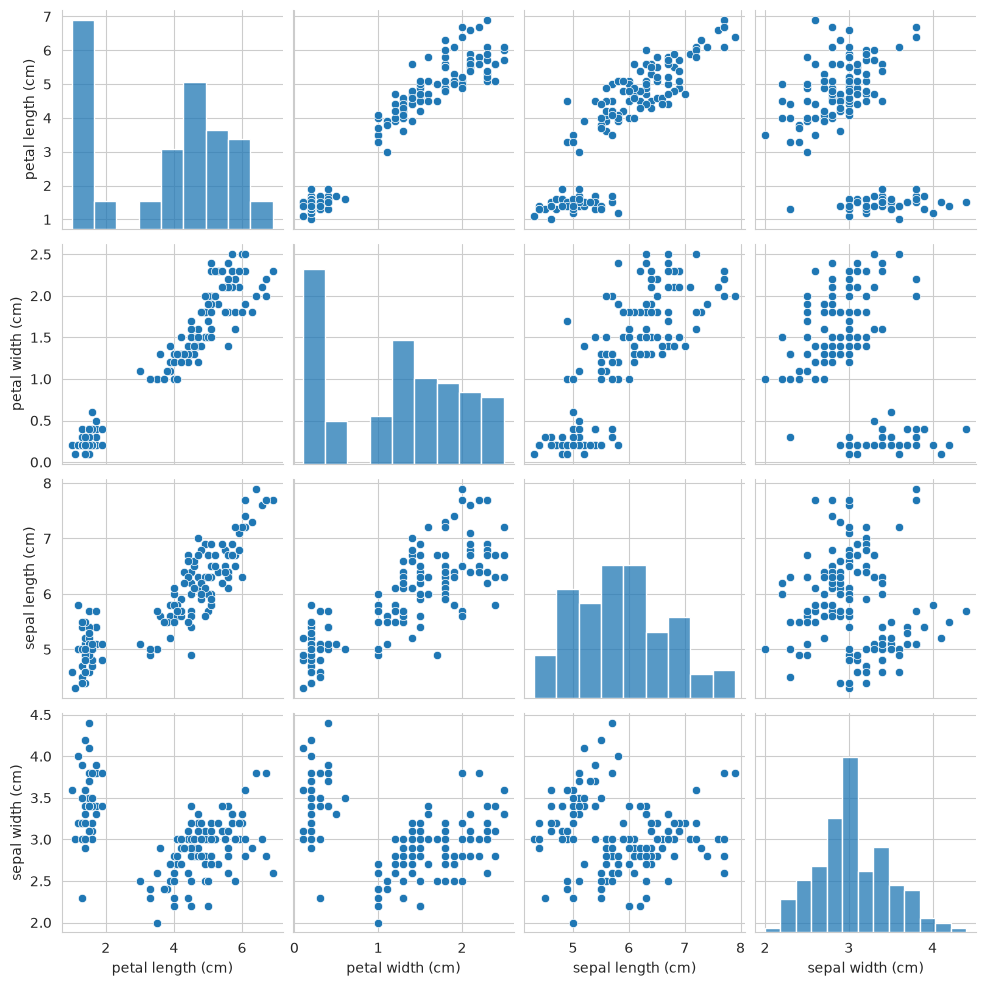

In [20]:
# Create Two Seaborn pair plots showing various aspects of the data points and its classes
sns.set_style("whitegrid")
plt.figure(figsize=(5,5))
Pairplot_graph1 = sns.pairplot(iris_DF, hue="Species", palette= "bright")
plt.show()

# This pairplot will show what the K-means clustering algorithm "sees" about the iris dataset
plt.figure(figsize=(5,5))
iris_X = iris_DF[["petal length (cm)", "petal width (cm)", "sepal length (cm)", "sepal width (cm)"]]
Pairplot_graph2 = sns.pairplot(iris_X)
plt.show()

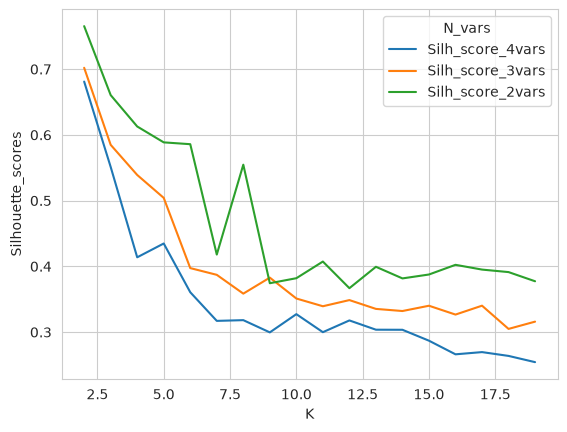

In [22]:
# Explore a range of 2 to 20 for "K" and create silhouette scores using the same models and datasets as for the elbow plot. 
kay2=[]
Silh_d4 = []
Silh_d3 = []
Silh_d2 = []

for k in range(2, 20):
    kmeanClusterModel4 = KMeans(n_clusters=k)
    kmeanClusterModel3 = KMeans(n_clusters=k)
    kmeanClusterModel2 = KMeans(n_clusters=k)
    kmeanClusterModel4.fit(iris_X4)
    kmeanClusterModel3.fit(iris_X3)
    kmeanClusterModel2.fit(iris_X2)
    kay2.append(k)
    Silh_d4.append(metrics.silhouette_score(iris_X4, kmeanClusterModel4.labels_, metric="euclidean"))
    Silh_d3.append(metrics.silhouette_score(iris_X3, kmeanClusterModel3.labels_, metric="euclidean"))
    Silh_d2.append(metrics.silhouette_score(iris_X2, kmeanClusterModel2.labels_, metric="euclidean"))

Silh_data = pd.DataFrame(list(zip(kay2, Silh_d4, Silh_d3, Silh_d2)), columns=["K", "Silh_score_4vars", "Silh_score_3vars", "Silh_score_2vars"])
Silh_graph_DF = Silh_data.melt("K", var_name="N_vars", value_name="Silhouette_scores")
Silh_graph = sns.lineplot(data=Silh_graph_DF, x="K", y="Silhouette_scores", hue="N_vars")

plt.show()

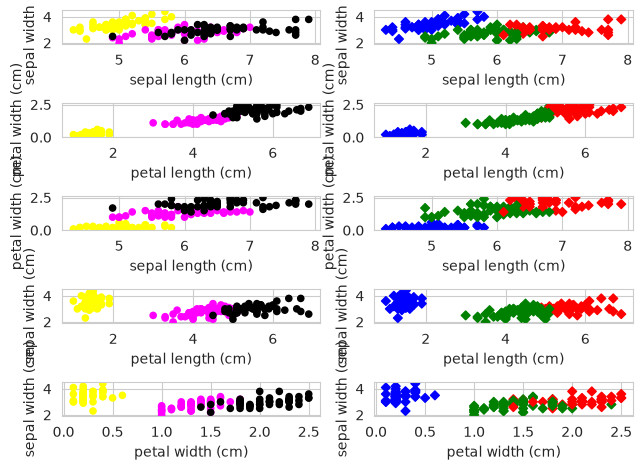

In [21]:
# Having determined 3 as a suitable number of clusters, Create a model and graph its performance against the known Species classes.

# Create a K-means Cluster model using 3 clusters and train it on the iris datasets four feature-variables
kmeanClusterModel = KMeans(n_clusters=3)
kmeanClusterModel.fit(iris_X)
iris_X["Pred_Cluster_Membership"] = kmeanClusterModel.predict(iris_X)

# Add Species labels, Create color dictionaries and apply them to the data
iris_X["Species"]=iris_DF["Species"]
colors1 = {"2":"red", "0":"green", "1":"blue"}
colors2 = {"2":"black", "0":"yellow", "1":"magenta"}
iris_X["Pred_Cluster_Membership"]=iris_X["Pred_Cluster_Membership"].astype(str).replace(colors1)
iris_X["Species"]=iris_X["Species"].astype(str).replace(colors2)

# Plot predicted cluster memberships and compare with the known classes.
fig, ((image1, image2), (image3, image4), (image5, image6), (image7, image8), (image9, image10)) = plt.subplots(5,2)
iris_X.plot("sepal length (cm)","sepal width (cm)", kind="scatter", marker="o", c="Species", ax=image1)
iris_X.plot("sepal length (cm)","sepal width (cm)", kind="scatter", marker="D", c="Pred_Cluster_Membership", ax=image2)
iris_X.plot("petal length (cm)","petal width (cm)", kind="scatter", marker="o", c="Species", ax=image3)
iris_X.plot("petal length (cm)","petal width (cm)", kind="scatter", marker="D", c="Pred_Cluster_Membership", ax=image4)
iris_X.plot("sepal length (cm)","petal width (cm)", kind="scatter", marker="o", c="Species", ax=image5)
iris_X.plot("sepal length (cm)","petal width (cm)", kind="scatter", marker="D", c="Pred_Cluster_Membership", ax=image6)
iris_X.plot("petal length (cm)","sepal width (cm)", kind="scatter", marker="o", c="Species", ax=image7)
iris_X.plot("petal length (cm)","sepal width (cm)", kind="scatter", marker="D", c="Pred_Cluster_Membership", ax=image8)
iris_X.plot("petal width (cm)","sepal width (cm)", kind="scatter", marker="o", c="Species", ax=image9)
iris_X.plot("petal width (cm)","sepal width (cm)", kind="scatter", marker="D", c="Pred_Cluster_Membership", ax=image10)
fig.tight_layout()
plt.show()